In [1]:

# --- Environment setup ---
# If running in a fresh environment, uncomment:
# %pip install datasets torch matplotlib

import re
import io
import json
import math
import random
from collections import Counter, defaultdict, deque
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

# Flip to False once you have internet access and want the real HF corpora.
OFFLINE_MODE = False

# Requested corpus size per class once running against the real HF datasets (OFFLINE_MODE=False).
# Set above 8,000 to leave headroom: loaders request this many *candidate* rows, but the final
# balanced count per class = min(deduped yield across all 4 sources), so a buffer above your
# actual target absorbs losses from de-duplication and length filtering.
TARGET_SAMPLES_PER_CLASS = 10000

# Binary classifier now -- "personal" and "working" memory were dropped:
# personal-data extraction happens downstream via span/entity extraction over
# arbitrary text, not via a whole-sentence memory-type label.
LABELS = ["semantic", "episodic"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL = {i: l for l, i in LABEL2IDX.items()}

OUT_DIR = Path("artifacts")
OUT_DIR.mkdir(exist_ok=True)


Using device: mps



## Phase 1 — Data Aggregation

Each loader below pulls from one or more real Hugging Face corpora, extracts the field(s)
that match the target linguistic profile, normalizes it, and returns a deduplicated list of
clean strings. `semantic` and `episodic` each merge **4 sources** (see `_merge_sources`)
instead of a single dataset, so the model sees varied sentence length, topic, and register
within each class rather than memorizing one source's formatting quirks.

**Design choice — stopwords are kept, not stripped.** Pronouns and function words
(`i`, `my`, `you`, `we`) plus tense markers (`yesterday`, `last week`, `remember when`)
are the strongest signals separating `episodic` (first-person, past-tense, situated in
time) from `semantic` (third-person, atemporal, objective). Removing them the way a
generic text-classification pipeline would throws away exactly the signal this
classifier depends on.


In [2]:

# --- Text normalization utilities ---

MIN_CHARS, MAX_CHARS = 8, 300

def clean_text(t: str) -> str:
    if t is None:
        return ""
    t = t.replace("_comma_", ",")          # empathetic_dialogues artifact
    t = re.sub(r"\s+", " ", t).strip()
    return t

def is_valid(t: str) -> bool:
    return bool(t) and MIN_CHARS <= len(t) <= MAX_CHARS


In [3]:
# Make sure to run: pip install datasets
from datasets import DatasetDict, concatenate_datasets, load_dataset


def clean_text(text):
    """Basic helper to ensure string sanitation."""
    if not text:
        return ""
    return str(text).strip().replace("\n", " ")


def is_valid(text):
    """Filters out empty or overly short sentences."""
    return len(text.split()) > 3


def load_all_splits(dataset_name, **kwargs):
    ds = load_dataset(dataset_name, **kwargs)
    if isinstance(ds, DatasetDict):
        splits = list(ds.values())
        if len(splits) == 1:
            return splits[0]
        return concatenate_datasets(splits)
    return ds


def _merge_sources(source_fns, limit, rng_seed=SEED):
    # Round-robins across several (name, fn) loaders, dedupes globally, and
    # shuffles so the final corpus isn't dominated by whichever source is
    # first or biggest. Each source is wrapped so one failing/rate-limited
    # dataset doesn't take the whole class down -- it just contributes less
    # variance instead of crashing the whole aggregation step.
    rng = random.Random(rng_seed)
    per_source_cap = max(200, math.ceil(limit / max(1, len(source_fns))) * 2)
    pooled, seen = [], set()
    for name, fn in source_fns:
        try:
            chunk = fn(limit=per_source_cap)
            added = 0
            for t in chunk:
                if t not in seen:
                    seen.add(t)
                    pooled.append(t)
                    added += 1
            print(f"    + {name:28s}: {added} unique rows")
        except Exception as exc:
            print(f"    ! {name:28s}: skipped ({type(exc).__name__}: {exc})")
    rng.shuffle(pooled)
    return pooled[:limit]


# --- Semantic Memory: multiple sources for register/length/topic variance ---
# Single-source (wiki_qa only) meant the model was learning "Q&A snippet
# formatting" rather than "objective/atemporal fact". Mixing in SQuAD
# (dense encyclopedic paragraphs), SciQ (science explanations) and
# OpenBookQA (terse one-clause facts) spreads out sentence length, domain,
# and phrasing style while keeping the third-person/no-episodic-time signal.

def load_semantic_wikiqa(limit=1000000):
    '''microsoft/wiki_qa -> 'answer' field (Wikipedia QA snippets).'''
    ds = load_all_splits("microsoft/wiki_qa", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row["answer"])
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_squad(limit=1000000):
    '''rajpurkar/squad -> 'context' field, split into sentences
    (dense encyclopedic paragraphs -> individual factual sentences).'''
    ds = load_all_splits("rajpurkar/squad")
    texts, seen = [], set()
    seen_context = set()
    for row in ds:
        ctx = row.get("context", "")
        if ctx in seen_context:
            continue
        seen_context.add(ctx)
        for sent in re.split(r"(?<=[.!?])\s+", ctx):
            t = clean_text(sent)
            if is_valid(t) and t not in seen:
                seen.add(t)
                texts.append(t)
            if len(texts) >= limit:
                break
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_sciq(limit=1000000):
    '''allenai/sciq -> 'support' field (short science-fact explanations).'''
    ds = load_all_splits("allenai/sciq")
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row.get("support", ""))
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_openbookqa(limit=1000000):
    '''allenai/openbookqa (additional config) -> 'fact1' field
    (terse single-clause facts -- adds short-sentence variance).'''
    ds = load_all_splits("allenai/openbookqa", name="additional")
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row.get("fact1", ""))
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_memory(limit=1000000):
    '''Semantic Memory: Objective, atemporal facts & definitions.
    Merged from 4 sources (wiki_qa, squad, sciq, openbookqa) for
    register/length/topic variance -- see _merge_sources.'''
    print("  Aggregating semantic memory from 4 sources...")
    return _merge_sources(
        [
            ("wiki_qa", load_semantic_wikiqa),
            ("squad_context_sentences", load_semantic_squad),
            ("sciq_support", load_semantic_sciq),
            ("openbookqa_fact1", load_semantic_openbookqa),
        ],
        limit=limit,
    )


# --- Episodic Memory: multiple sources for register/length/topic variance ---
# Single-source (empathetic_dialogues only) meant every example was a short,
# emotionally-flavored conversational opener. Adding Reddit TIFU (longer real
# autobiographical anecdotes), ROCStories (short past-tense commonsense
# narratives) and DailyDialog (everyday recount-style utterances) spreads out
# length, formality, and topic while keeping the first-person/past-event signal.

def load_episodic_empathetic(limit=1000000):
    '''facebook/empathetic_dialogues -> 'prompt' field.'''
    try:
        ds = load_all_splits("facebook/empathetic_dialogues", trust_remote_code=True)
        texts, seen = [], set()
        for row in ds:
            t = clean_text(row["prompt"])
            if is_valid(t) and t not in seen:
                seen.add(t)
                texts.append(t)
            if len(texts) >= limit:
                break
        return texts[:limit]
    except Exception as exc:
        print(f"    empathetic_dialogues HF load failed ({type(exc).__name__}): {exc}")
        print("    Falling back to direct empatheticdialogues.tar.gz download...")
        import csv
        import io as _io
        import os
        import ssl
        import tarfile
        import tempfile
        import urllib.request

        archive_path = OUT_DIR / "empatheticdialogues.tar.gz"
        if not archive_path.exists():
            url = "https://dl.fbaipublicfiles.com/parlai/empatheticdialogues/empatheticdialogues.tar.gz"
            ctx = ssl._create_unverified_context()
            fd, tmp_path = tempfile.mkstemp(suffix=".tar.gz")
            os.close(fd)
            try:
                with urllib.request.urlopen(url, context=ctx) as resp, open(tmp_path, "wb") as out:
                    while True:
                        chunk = resp.read(1024 * 1024)
                        if not chunk:
                            break
                        out.write(chunk)
                os.replace(tmp_path, archive_path)
            finally:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)

        texts, seen = [], set()
        with tarfile.open(archive_path, "r:gz") as tar:
            csv_members = sorted(
                [m for m in tar.getmembers() if m.name.endswith(".csv")],
                key=lambda m: m.name,
            )
            for member_info in csv_members:
                member = tar.extractfile(member_info)
                if member is None:
                    continue
                reader = csv.DictReader(_io.TextIOWrapper(member, encoding="utf-8"))
                for row in reader:
                    t = clean_text(row.get("prompt", ""))
                    if is_valid(t) and t not in seen:
                        seen.add(t)
                        texts.append(t)
                    if len(texts) >= limit:
                        break
                if len(texts) >= limit:
                    break
        return texts[:limit]


def load_episodic_reddit_tifu(limit=1000000):
    '''reddit_tifu (short config) -> 'tldr' field
    (real one/two-sentence autobiographical anecdotes, past tense).'''
    ds = load_all_splits("reddit_tifu", name="short", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row.get("tldr", ""))
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_episodic_rocstories(limit=1000000):
    '''ROCStories -> concatenated sentence1..sentence5 fields
    (short past-tense commonsense narratives).'''
    ds = load_all_splits("Ximing/ROCStories")
    texts, seen = [], set()
    sent_keys = [f"sentence{i}" for i in range(1, 6)]
    for row in ds:
        parts = [clean_text(row[k]) for k in sent_keys if k in row and row[k]]
        t = clean_text(" ".join(parts))
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_episodic_dailydialog(limit=1000000):
    '''li2017dailydialog/daily_dialog -> 'dialog' field, flattened
    (everyday recount-style utterances -- adds conversational-but-mundane variance).'''
    ds = load_all_splits("li2017dailydialog/daily_dialog", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        for utt in row.get("dialog", []):
            t = clean_text(utt)
            if is_valid(t) and t not in seen:
                seen.add(t)
                texts.append(t)
            if len(texts) >= limit:
                break
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_episodic_memory(limit=1000000):
    '''Episodic Memory: Past-tense, situational, first-person events.
    Merged from 4 sources (empathetic_dialogues, reddit_tifu, ROCStories,
    daily_dialog) for register/length/topic variance -- see _merge_sources.'''
    print("  Aggregating episodic memory from 4 sources...")
    return _merge_sources(
        [
            ("empathetic_dialogues", load_episodic_empathetic),
            ("reddit_tifu_tldr", load_episodic_reddit_tifu),
            ("rocstories", load_episodic_rocstories),
            ("daily_dialog_utterances", load_episodic_dailydialog),
        ],
        limit=limit,
    )


HF_LOADERS = {
    "semantic": load_semantic_memory,
    "episodic": load_episodic_memory,
}


/Users/sasidharjasty/DMC/env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

# --- Offline synthetic fallback (only used when OFFLINE_MODE = True) ---
# Templated generators that mimic each source's linguistic profile, so the rest of the
# notebook (vectorizer, MLP, training, evaluation) can be exercised without internet access.

def _build_synthetic_corpus(seed=SEED, n_per_class=500):
    rng = random.Random(seed)

    semantic_templates = [
        "The {concept} is defined as the {def_}.",
        "{Concept} refers to a process by which {process}.",
        "In physics, {concept} describes the relationship between {a} and {b}.",
        "The capital of {country} is {city}.",
        "{Concept} was first described in {year} by researchers studying {field}.",
        "A {concept} is a type of {category} found in {field}.",
    ]
    episodic_templates = [
        "Yesterday I went to the {place} and met {person}.",
        "Last week I was feeling {adj} after the {event}.",
        "We celebrated my {relation}'s birthday at {place} last month.",
        "I remember when I first {action} back in {year}.",
        "During the trip, I visited {place} and it was {adj}.",
        "This morning I {action} before heading to work.",
        "Last summer I {action} with {person} in {place}.",
        "A few months ago I {action} and it felt {adj}.",
        "Back in {year} I {action} while visiting {place}.",
        "Earlier this year I {action} with my {relation}.",
    ]
    fillers = {
        "adj": ["curious","happy","nervous","excited","calm","tired","anxious","confident"],
        "place": ["Paris","the mountains","a small town","New York","the beach","the library","a cafe"],
        "concept": ["photosynthesis","gravity","inflation","democracy","osmosis","entropy"],
        "Concept": ["Photosynthesis","Gravity","Inflation","Democracy","Osmosis","Entropy"],
        "def_": ["conversion of light into chemical energy","force attracting masses",
                 "rise in prices over time","measure of disorder in a system"],
        "process": ["plants convert sunlight into energy","cells divide",
                    "water moves across a membrane","heat flows between two bodies"],
        "a": ["mass","voltage","supply","pressure"],
        "b": ["acceleration","current","demand","volume"],
        "category": ["organelle","economic indicator","political system","physical law"],
        "country": ["France","Japan","Germany","Brazil","Canada"],
        "city": ["Paris","Tokyo","Berlin","Brasilia","Ottawa"],
        "year": ["1928","1953","1687","2001","1867"],
        "field": ["genetics","chemistry","astronomy","economics"],
        "person": ["Sarah","the client","Dr. Lee","my manager","the team"],
        "event": ["exam","interview","storm","deadline"],
        "relation": ["sister","brother","mom","friend","cousin"],
        "action": ["rode a bike","cooked dinner","flew on a plane","went for a run","read a book"],
    }

    def fill(t):
        out = t
        for k, vals in fillers.items():
            if "{" + k + "}" in out:
                out = out.replace("{" + k + "}", rng.choice(vals))
        return out

    def gen(templates, n):
        return [fill(rng.choice(templates)) for _ in range(n)]

    return {
        "semantic": gen(semantic_templates, n_per_class),
        "episodic": gen(episodic_templates, n_per_class),
    }



In [ ]:

# --- Build the unified corpus ---

def build_balanced_records(raw_data, seed=SEED, sample_frac=1.0):
    """Shuffle each class independently, then cut a balanced slice.

    sample_frac < 1.0 lets the training loop draw a different subset each epoch
    instead of reusing the exact same rows every time.
    """
    rng = random.Random(seed)
    by_label = {}
    for label, texts in raw_data.items():
        shuffled = list(texts)
        rng.shuffle(shuffled)
        take = max(1, int(len(shuffled) * sample_frac))
        by_label[label] = shuffled[:take]

    min_count = min(len(v) for v in by_label.values())
    records = []
    for label, texts in by_label.items():
        records.extend({"text": t, "label": label} for t in texts[:min_count])

    rng.shuffle(records)
    return records, min_count


def merge_novel_dataset(raw_data, novel_path=Path("data/novel_classifier_dataset.json")):
    """Add the labeled novel dataset into the already-loaded class buckets."""
    if not novel_path.exists():
        print(f"Novel dataset not found at {novel_path}; skipping merge.")
        return raw_data

    with open(novel_path) as f:
        novel_rows = json.load(f)

    added = defaultdict(int)
    for row in novel_rows:
        label = row.get("label")
        text = clean_text(row.get("text", ""))
        if label not in raw_data or not is_valid(text):
            continue
        raw_data[label].append(text)
        added[label] += 1

    for label, count in added.items():
        print(f"Added {count} novel {label} rows from {novel_path.name}")
    return raw_data


if OFFLINE_MODE:
    print("OFFLINE_MODE=True -> using synthetic stand-in corpus (no internet required).")
    raw_data = _build_synthetic_corpus(n_per_class=600)
else:
    print("OFFLINE_MODE=False -> pulling real corpora from the Hugging Face Hub...")
    try:
        raw_data = {label: fn(limit=TARGET_SAMPLES_PER_CLASS) for label, fn in HF_LOADERS.items()}
    except Exception as exc:
        print(f"HF download failed ({type(exc).__name__}): {exc}")
        print("Falling back to synthetic stand-in corpus so the notebook can continue.")
        raw_data = _build_synthetic_corpus(n_per_class=600)

raw_data = merge_novel_dataset(raw_data)

for label, texts in raw_data.items():
    print(f"{label:10s}: {len(texts)} raw samples")

# Build one balanced corpus for the initial split, but shuffle before cutting so
# the selected rows are not always the same prefix of each source.
records, min_count = build_balanced_records(raw_data, seed=SEED, sample_frac=1.0)
print(f"\nBalancing both classes to {min_count} samples each")
print(f"Total unified corpus: {len(records)} records")

with open(OUT_DIR / "corpus.json", "w") as f:
    json.dump(records, f, indent=2)



OFFLINE_MODE=False -> pulling real corpora from the Hugging Face Hub...
  Aggregating semantic memory from 4 sources...
    + wiki_qa                     : 5000 unique rows
    ! squad_context_sentences     : skipped (TypeError: must be called with a dataclass type or instance)
    + sciq_support                : 5000 unique rows
    + openbookqa_fact1            : 1282 unique rows
  Aggregating episodic memory from 4 sources...
    empathetic_dialogues HF load failed (FileNotFoundError): https://dl.fbaipublicfiles.com/parlai/empatheticdialogues/empatheticdialogues.tar.gz
    Falling back to direct empatheticdialogues.tar.gz download...
    + empathetic_dialogues        : 5000 unique rows
    + reddit_tifu_tldr            : 5000 unique rows
    ! rocstories                  : skipped (DatasetNotFoundError: Dataset 'Ximing/ROCStories' doesn't exist on the Hub or cannot be accessed.)


Generating train split:   0%|          | 0/11118 [00:00<?, ? examples/s]

    ! daily_dialog_utterances     : skipped (DatasetGenerationError: An error occurred while generating the dataset)
semantic  : 10000 raw samples
episodic  : 10000 raw samples

Balancing both classes to 10000 samples each
Total unified corpus: 20000 records


In [6]:

# --- Stratified train / val / test split (pure Python, no sklearn) ---

def stratified_split(records, val_frac=0.15, test_frac=0.15, seed=SEED):
    by_label = defaultdict(list)
    for r in records:
        by_label[r["label"]].append(r)

    train, val, test = [], [], []
    split_rng = random.Random(seed)
    for label, items in by_label.items():
        split_rng.shuffle(items)
        n = len(items)
        n_val = int(n * val_frac)
        n_test = int(n * test_frac)
        val.extend(items[:n_val])
        test.extend(items[n_val:n_val + n_test])
        train.extend(items[n_val + n_test:])

    split_rng.shuffle(train); split_rng.shuffle(val); split_rng.shuffle(test)
    return train, val, test

train_records, val_records, test_records = stratified_split(records)
print(f"train={len(train_records)}  val={len(val_records)}  test={len(test_records)}")


train=14000  val=3000  test=3000


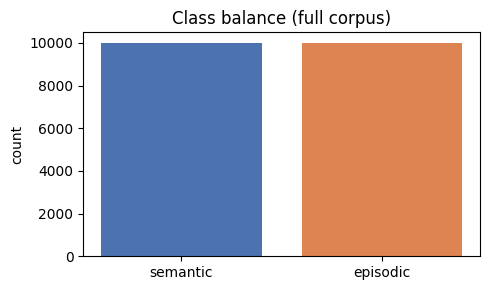


Sample records:
  [semantic  ] AM radio waves are used to carry commercial radio signals in the frequency range from 540 to 1600 kHz. The abbreviation AM stands for amplitude modulation, which is the method for placing information on these waves. (See Figure 24.12. ) A carrier wave having the basic frequency of the radio station, say 1530 kHz, is varied or modulated in amplitude by an audio signal. The resulting wave has a constant frequency, but a varying amplitude. A radio receiver tuned to have the same resonant frequency as the carrier wave can pick up the signal, while rejecting the many other frequencies impinging on its antenna. The receiver’s circuitry is designed to respond to variations in amplitude of the carrier wave to replicate the original audio signal. That audio signal is amplified to drive a speaker or perhaps to be recorded.
  [episodic  ] I beat level 150 on my favorite game Grim Dawn this morning. I've been grinding levels all week!


In [7]:

# --- Sanity check: class balance + example rows ---

fig, ax = plt.subplots(figsize=(5, 3))
counts = [sum(1 for r in records if r["label"] == l) for l in LABELS]
ax.bar(LABELS, counts, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_title("Class balance (full corpus)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

print("\nSample records:")
for label in LABELS:
    example = next(r["text"] for r in records if r["label"] == label)
    print(f"  [{label:10s}] {example}")



## Phase 2 — Custom TF-IDF Vectorizer (pure Python, no sklearn)

Standard TF-IDF, built from scratch with `re` + `collections.Counter` + `math.log`:

- **Tokenizer**: lowercase word tokens + bigrams (`use_bigrams=True`) — bigrams capture
  short imperative phrases like `"turn_off"` or `"schedule_a"` that unigrams alone miss.
- **Vocabulary pruning**: `min_df` / `max_df_ratio` drop terms that are too rare (noise) or
  too common (uninformative across all four classes), then keep the top `max_features` by
  document frequency.
- **Weighting**: sublinear TF (`1 + log(tf)`) dampens the effect of a term repeated many
  times in one document, combined with smoothed IDF (`ln((1+N)/(1+df)) + 1`).
- **Normalization**: each vector is L2-normalized, which is what lets a plain dot product
  behave like cosine similarity and keeps the MLP's input scale stable across documents of
  very different lengths.


In [8]:

TOKEN_RE = re.compile(r"[a-zA-Z0-9:_/-]+")

def tokenize(text: str, use_bigrams: bool = True):
    tokens = [t.lower() for t in TOKEN_RE.findall(text)]
    if use_bigrams:
        bigrams = [f"{a}_{b}" for a, b in zip(tokens, tokens[1:])]
        return tokens + bigrams
    return tokens


class TFIDFVectorizer:
    '''Deterministic TF-IDF vectorizer implemented with base Python only
    (re, collections.Counter, math) — no scikit-learn.'''

    def __init__(self, max_features=10000, min_df=2, max_df_ratio=0.9,
                 use_bigrams=True, sublinear_tf=True):
        self.max_features = max_features
        self.min_df = min_df
        self.max_df_ratio = max_df_ratio
        self.use_bigrams = use_bigrams
        self.sublinear_tf = sublinear_tf
        self.vocab_ = {}   # token -> column index
        self.idf_ = {}     # token -> idf weight

    def fit(self, texts):
        n_docs = len(texts)
        df = Counter()
        for text in texts:
            df.update(set(tokenize(text, self.use_bigrams)))

        max_df_count = self.max_df_ratio * n_docs
        candidates = [
            (tok, c) for tok, c in df.items()
            if self.min_df <= c <= max_df_count
        ]
        # Keep the most broadly-attested terms up to the feature cap.
        candidates.sort(key=lambda x: -x[1])
        candidates = candidates[: self.max_features]

        self.vocab_ = {tok: i for i, (tok, _) in enumerate(candidates)}
        self.idf_ = {
            tok: math.log((1 + n_docs) / (1 + c)) + 1.0
            for tok, c in candidates
        }
        return self

    def _vectorize_one(self, text):
        tokens = tokenize(text, self.use_bigrams)
        counts = Counter(t for t in tokens if t in self.vocab_)
        vec = torch.zeros(len(self.vocab_))
        for tok, c in counts.items():
            tf = 1 + math.log(c) if self.sublinear_tf else float(c)
            vec[self.vocab_[tok]] = tf * self.idf_[tok]
        norm = torch.norm(vec, p=2)
        if norm > 0:
            vec = vec / norm
        return vec

    def transform(self, texts):
        return torch.stack([self._vectorize_one(t) for t in texts])

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)

    def save(self, path):
        with open(path, "w") as f:
            json.dump({
                "vocab": self.vocab_,
                "idf": self.idf_,
                "max_features": self.max_features,
                "use_bigrams": self.use_bigrams,
                "sublinear_tf": self.sublinear_tf,
            }, f)

    @classmethod
    def load(cls, path):
        with open(path) as f:
            data = json.load(f)
        vec = cls(max_features=data["max_features"],
                   use_bigrams=data["use_bigrams"],
                   sublinear_tf=data["sublinear_tf"])
        vec.vocab_ = data["vocab"]
        vec.idf_ = data["idf"]
        return vec


In [9]:

vectorizer = TFIDFVectorizer(max_features=10000, min_df=2, max_df_ratio=0.9,
                              use_bigrams=True, sublinear_tf=True)

X_train = vectorizer.fit_transform([r["text"] for r in train_records])
y_train = torch.tensor([LABEL2IDX[r["label"]] for r in train_records], dtype=torch.long)

X_val = vectorizer.transform([r["text"] for r in val_records])
y_val = torch.tensor([LABEL2IDX[r["label"]] for r in val_records], dtype=torch.long)

X_test = vectorizer.transform([r["text"] for r in test_records])
y_test = torch.tensor([LABEL2IDX[r["label"]] for r in test_records], dtype=torch.long)

vocab_size = len(vectorizer.vocab_)
sparsity = (X_train == 0).float().mean().item()
print(f"Vocabulary size: {vocab_size}")
print(f"X_train shape:   {tuple(X_train.shape)}")
print(f"Sparsity:        {sparsity:.2%} of entries are zero")

vectorizer.save(OUT_DIR / "tfidf_vectorizer.json")


Vocabulary size: 10000
X_train shape:   (14000, 10000)
Sparsity:        99.69% of entries are zero



## PyTorch `Dataset` / `DataLoader`


In [10]:

class MemoryTextDataset(Dataset):
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 128

train_loader = DataLoader(MemoryTextDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(MemoryTextDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(MemoryTextDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)



## Phase 2 — The MLP Classifier (pure PyTorch)

A small feed-forward network: `Linear -> BatchNorm -> ReLU -> Dropout`, stacked twice,
then a final `Linear` to 4 logits. `BatchNorm1d` speeds up convergence on TF-IDF's
high-dimensional, sparsity-heavy input; `Dropout` plus `weight_decay` in the optimizer
keep it from memorizing lexical quirks of any one HF source.


In [11]:

class MemoryClassifierMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(1024, 512,256), num_classes=2, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MemoryClassifierMLP(input_dim=vocab_size, hidden_dims=(512, 128),
                             num_classes=len(LABELS), dropout=0.3).to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")


MemoryClassifierMLP(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total trainable parameters: 5,187,714



## Training loop — early stopping + LR scheduling

Standard supervised training: `CrossEntropyLoss` + `AdamW`, with `ReduceLROnPlateau`
halving the learning rate when validation loss stalls, and early stopping that restores
the best-validation-loss weights once patience is exhausted.


In [13]:

def evaluate_loss_acc(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def sample_epoch_records(records, seed, sample_frac=0.85):
    """Shuffle the training split and cut a fresh balanced subset each epoch."""
    by_label = defaultdict(list)
    for record in records:
        by_label[record["label"]].append(record)

    rng = random.Random(seed)
    sampled = []
    for label, items in by_label.items():
        shuffled = list(items)
        rng.shuffle(shuffled)
        take = max(1, int(len(shuffled) * sample_frac))
        sampled.extend(shuffled[:take])

    rng.shuffle(sampled)
    return sampled


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

EPOCHS = 40
PATIENCE = 7
EPOCH_SAMPLE_FRAC = 0.85

best_val_loss = float("inf")
best_state = None
patience_ctr = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    epoch_records = sample_epoch_records(train_records, seed=SEED + epoch, sample_frac=EPOCH_SAMPLE_FRAC)
    X_train_epoch = vectorizer.transform([r["text"] for r in epoch_records])
    y_train_epoch = torch.tensor([LABEL2IDX[r["label"]] for r in epoch_records], dtype=torch.long)
    train_loader = DataLoader(MemoryTextDataset(X_train_epoch, y_train_epoch), batch_size=BATCH_SIZE, shuffle=True)

    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss, train_acc = running_loss / total, correct / total
    val_loss, val_acc = evaluate_loss_acc(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} | train_rows {len(epoch_records):5d} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

model.load_state_dict(best_state)


Epoch 01 | train_rows 11900 | train_loss 0.0054 acc 0.9982 | val_loss 0.1320 acc 0.9717
Epoch 02 | train_rows 11900 | train_loss 0.0275 acc 0.9897 | val_loss 0.0620 acc 0.9810
Epoch 03 | train_rows 11900 | train_loss 0.0120 acc 0.9954 | val_loss 0.0526 acc 0.9857
Epoch 04 | train_rows 11900 | train_loss 0.0035 acc 0.9987 | val_loss 0.0608 acc 0.9847
Epoch 05 | train_rows 11900 | train_loss 0.0016 acc 0.9997 | val_loss 0.0640 acc 0.9853
Epoch 06 | train_rows 11900 | train_loss 0.0014 acc 0.9996 | val_loss 0.0667 acc 0.9853
Epoch 07 | train_rows 11900 | train_loss 0.0006 acc 1.0000 | val_loss 0.0659 acc 0.9860
Epoch 08 | train_rows 11900 | train_loss 0.0003 acc 1.0000 | val_loss 0.0669 acc 0.9860
Epoch 09 | train_rows 11900 | train_loss 0.0004 acc 0.9999 | val_loss 0.0689 acc 0.9863
Epoch 10 | train_rows 11900 | train_loss 0.0003 acc 0.9999 | val_loss 0.0687 acc 0.9850

Early stopping at epoch 10 (best val_loss=0.0526)


<All keys matched successfully>

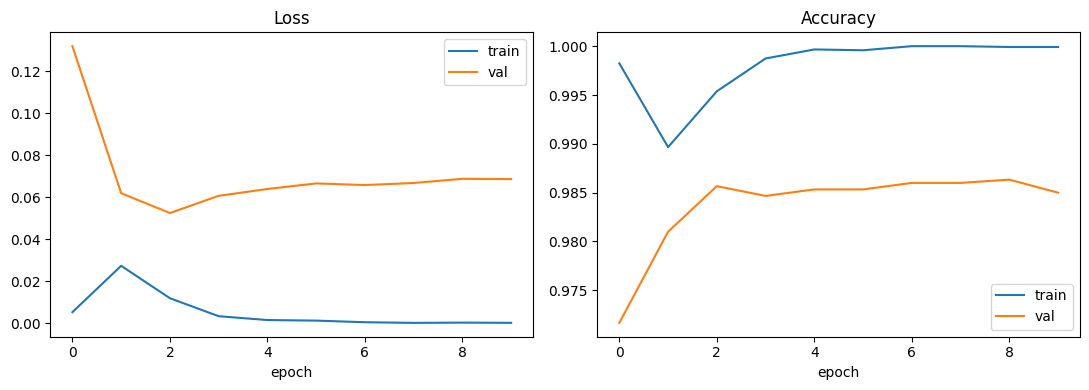

In [14]:

# --- Training curves ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.show()



## Evaluation — manual metrics (no sklearn)

Confusion matrix, per-class precision/recall/F1, and overall accuracy, all computed with
plain `torch` tensor operations.


In [15]:

def confusion_matrix(y_true, y_pred, num_classes):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def classification_report(y_true, y_pred, labels):
    num_classes = len(labels)
    cm = confusion_matrix(y_true, y_pred, num_classes)
    report = {}
    for i, label in enumerate(labels):
        tp = cm[i, i].item()
        fp = cm[:, i].sum().item() - tp
        fn = cm[i, :].sum().item() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = cm[i, :].sum().item()
        report[label] = {"precision": precision, "recall": recall, "f1": f1, "support": support}
    accuracy = torch.diag(cm).sum().item() / cm.sum().item()
    return report, accuracy, cm


model.eval()
with torch.no_grad():
    test_logits = model(X_test.to(DEVICE))
    test_preds = test_logits.argmax(1).cpu()

report, accuracy, cm = classification_report(y_test.tolist(), test_preds.tolist(), LABELS)

print(f"Test accuracy: {accuracy:.4f}\n")
print(f"{'class':10s} {'precision':>10s} {'recall':>10s} {'f1':>10s} {'support':>10s}")
for label, m in report.items():
    print(f"{label:10s} {m['precision']:10.3f} {m['recall']:10.3f} {m['f1']:10.3f} {m['support']:10d}")


Test accuracy: 0.9770

class       precision     recall         f1    support
semantic        0.984      0.969      0.977       1500
episodic        0.970      0.985      0.977       1500


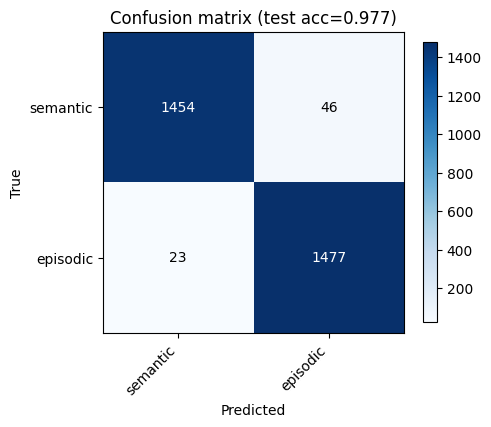

In [16]:

# --- Confusion matrix heatmap ---
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm.numpy(), cmap="Blues")
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (test acc={accuracy:.3f})")

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        val = cm[i, j].item()
        color = "white" if val > cm.max().item() / 2 else "black"
        ax.text(j, i, str(val), ha="center", va="center", color=color)

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()



## Save artifacts

The trained model weights, the TF-IDF vocabulary/IDF table, and the label map are saved
so the classifier can be loaded standalone by the downstream Phase 3 (SPO extraction /
storage routing) and Phase 4 (conflict resolution) components without retraining.


In [17]:

torch.save(model.state_dict(), OUT_DIR / "memory_classifier_mlp.pt")
vectorizer.save(OUT_DIR / "tfidf_vectorizer.json")
with open(OUT_DIR / "label_map.json", "w") as f:
    json.dump({"labels": LABELS, "label2idx": LABEL2IDX}, f, indent=2)

# Also persist the architecture hyperparams needed to reconstruct the model at load time.
with open(OUT_DIR / "model_config.json", "w") as f:
    json.dump({
        "input_dim": vocab_size,
        "hidden_dims": [512, 128],
        "num_classes": len(LABELS),
        "dropout": 0.3,
    }, f, indent=2)

print("Saved to:", [p.name for p in OUT_DIR.iterdir()])


Saved to: ['corpus.json', 'memory_classifier_mlp.pt', 'empatheticdialogues.tar.gz', 'label_map.json', 'tfidf_vectorizer.json', 'model_config.json']



## Inference demo — classify & route

A single deterministic function that takes raw text, vectorizes it with the fitted
TF-IDF vectorizer, runs it through the trained MLP, and returns the predicted memory
type plus a softmax confidence score. This confidence score is exactly the signal Phase 4
(adversarial conflict resolution) will use downstream to decide whether a new fact should
overwrite, supersede, or be rejected against an existing memory entry.


In [18]:

@torch.no_grad()
def classify_and_route(text: str, model=model, vectorizer=vectorizer):
    model.eval()
    vec = vectorizer.transform([text]).to(DEVICE)
    logits = model(vec)
    probs = torch.softmax(logits, dim=1).squeeze(0)
    pred_idx = int(probs.argmax())
    return {
        "text": text,
        "predicted_memory": IDX2LABEL[pred_idx],
        "confidence": round(probs[pred_idx].item(), 4),
        "distribution": {IDX2LABEL[i]: round(p.item(), 4) for i, p in enumerate(probs)},
    }


demo_examples = [
    "Water freezes at 0 degrees Celsius.",
    "Last weekend I visited my grandparents and helped them plant flowers.",

    "The Pacific Ocean is the largest ocean on Earth.",
    "I celebrated my birthday with a small group of close friends last year.",

    "The capital of Australia is Canberra.",
    "During winter break I learned how to ski for the first time.",

    "Photosynthesis converts sunlight into chemical energy.",
    "Last month I attended a live jazz concert downtown.",

    "The Great Wall of China was built over many centuries.",
    "I met my childhood best friend at a reunion last summer.",

    "Venus is the hottest planet in the solar system.",
    "Yesterday I accidentally left my backpack on the bus but got it back.",

    "The human body has 206 bones.",
    "Last fall I volunteered at a local food bank.",

    "Mount Everest is the tallest mountain above sea level.",
    "I watched the northern lights during a trip to Iceland.",

    "The speed of light is approximately 299,792 kilometers per second.",
    "When I was ten years old I broke my arm riding a bicycle.",

    "The Amazon rainforest produces a significant amount of Earth's oxygen.",
    "I once got caught in a thunderstorm while hiking.",

    "An octagon has eight sides.",
    "Last Christmas my family baked cookies together.",

    "Sharks are fish, not mammals.",
    "I visited the Grand Canyon during a family road trip.",

    "The chemical symbol for sodium is Na.",
    "Last year I completed my first half marathon.",

    "Honey never truly spoils if stored properly.",
    "I accidentally spilled coffee on my laptop during finals week.",

    "Earth revolves around the Sun once every year.",
    "Last spring I planted tomatoes in my backyard.",

    "A triangle's interior angles sum to 180 degrees.",
    "I won first place in a local chess tournament when I was younger.",

    "Python is an interpreted programming language.",
    "Last semester I presented my research at a student conference.",

    "The Moon orbits the Earth.",
    "I went camping beside a lake with my cousins last summer.",

    "Electricity flows through conductive materials.",
    "I learned to swim at a community pool when I was seven.",

    "Saturn is known for its prominent ring system.",
    "I watched a solar eclipse from a nearby park.",

    "Bats are the only mammals capable of sustained flight.",
    "I got lost while exploring an old city during vacation.",

    "The boiling point of water is 100 degrees Celsius at sea level.",
    "I found an old photo album while cleaning the attic.",

    "The Eiffel Tower is located in Paris.",
    "Last weekend I taught my younger cousin how to ride a bike.",

    "Penguins cannot fly.",
    "I spent an afternoon exploring a science museum with friends.",

    "Gold has the chemical symbol Au.",
    "I attended my first orchestra performance last month.",

    "A leap year has 366 days.",
    "I learned how to bake bread during the pandemic.",

    "The Sahara is the world's largest hot desert.",
    "I watched sea turtles hatch during a beach vacation."
]


for ex in demo_examples:
    result = classify_and_route(ex)
    print(f"[{result['predicted_memory']:10s} | conf={result['confidence']:.3f}] {ex}")


#while True:
#    user_input = input("\nEnter a text snippet (or 'exit' to quit): ")
#    if user_input.lower() in {"exit", "quit"}:
#        break
#    result = classify_and_route(user_input)
#    print(f"[{result['predicted_memory']:10s} | conf={result['confidence']:.3f}] {user_input}")
#    print("Distribution:", result["distribution"])



[semantic   | conf=0.992] Water freezes at 0 degrees Celsius.
[episodic   | conf=1.000] Last weekend I visited my grandparents and helped them plant flowers.
[semantic   | conf=1.000] The Pacific Ocean is the largest ocean on Earth.
[episodic   | conf=1.000] I celebrated my birthday with a small group of close friends last year.
[semantic   | conf=0.964] The capital of Australia is Canberra.
[episodic   | conf=0.996] During winter break I learned how to ski for the first time.
[semantic   | conf=1.000] Photosynthesis converts sunlight into chemical energy.
[episodic   | conf=1.000] Last month I attended a live jazz concert downtown.
[semantic   | conf=0.996] The Great Wall of China was built over many centuries.
[episodic   | conf=1.000] I met my childhood best friend at a reunion last summer.
[semantic   | conf=0.998] Venus is the hottest planet in the solar system.
[episodic   | conf=1.000] Yesterday I accidentally left my backpack on the bus but got it back.
[semantic   | conf=0.999


## Phase 3 (partial) — Personal Information Extraction (self vs. other)

The binary `semantic`/`episodic` classifier above tells you *what kind of memory* a
sentence is. It doesn't tell you *who the sentence is about*. A sentence can be
personal-flavored (preferences, traits, biographical facts, contact info, routines) while
still being about someone else entirely -- and that distinction matters a lot if these
extracted spans are going to be stored as facts about *this* user.

`extract_personal_info` below is a rule-based, dependency-free clause scanner (pure Python,
same "no external deps" philosophy as the TF-IDF vectorizer above) that:

1. Splits text into clauses (naive split on sentence-ending `.`/`!`/`?`/`;`, so
   compound subjects like "my friend and I" stay in one clause).
2. For each clause, decides who the **grammatical subject** is:
   - `"self"` — clause is led by `I`/`I'm`/`me`/`myself`, or by `my <attribute>` where
     `<attribute>` is something only the speaker themself can have (name, age, favorite,
     birthday, allergy, phone number, ...).
   - `"other"` — clause is led by a third-person pronoun (`he`/`she`/`they`/...), or by
     `my <relation>` where `<relation>` is another *person* (sister, friend, boss, coworker,
     ...) -- i.e. "my sister's favorite color" is information *about the sister*, not about
     the speaker, even though "my" appears.
   - `None` — no clear subject marker either way.
3. Only `"self"` clauses get scanned for personal-info categories (preference,
   identity/trait, biographical, routine/habit, contact/allergy, possession).

**Known limitation:** this is a lexical heuristic, not a real dependency parse. Multi-clause
sentences joined by "and"/"but" (e.g. "I love pizza and my sister hates it") are scored as
one unit, so a same-clause mention of another person can slip through as self. The
"Next steps" section below still calls out a proper spaCy dependency parse as the
production-grade version of this same idea.


In [19]:

# --- Personal Information Extraction: self vs. other ---
# Pure-Python / regex heuristic (no spaCy dependency) that finds personal-info
# clauses (preferences, traits, biography, routines, contact info) but only
# keeps the ones whose grammatical subject is the speaker themself.

# Nouns that denote *another* person -- if "my {noun}" leads a clause, the
# clause is about that person, not about the speaker, even though "my" appears.
OTHER_PERSON_NOUNS = {
    "sister", "brother", "mom", "mother", "dad", "father", "parent", "parents",
    "friend", "bestfriend", "cousin", "wife", "husband", "boyfriend", "girlfriend",
    "partner", "fiance", "fiancee", "boss", "coworker", "colleague", "manager",
    "teacher", "professor", "roommate", "neighbor", "neighbour", "grandma",
    "grandmother", "grandpa", "grandfather", "aunt", "uncle", "son", "daughter",
    "kid", "kids", "child", "children", "teammate", "client", "doctor", "dentist",
    "nephew", "niece", "classmate", "team", "coach", "landlord", "tenant",
}

# Attributes that only make sense as belonging to the speaker when phrased as
# "my {attribute}" at the head of a clause (name, age, favorite thing, ...).
SELF_ATTRIBUTE_NOUNS = {
    "name", "nickname", "age", "favorite", "favourite", "hobby", "hobbies",
    "job", "occupation", "birthday", "email", "phone", "number", "address",
    "allergy", "allergies", "blood", "zodiac", "personality", "height",
    "weight", "goal", "goals", "routine", "schedule",
}

_SELF_LEAD_RE = re.compile(r"^(i|i'm|i've|i'd|i'll|me|myself)\b")
_OTHER_PRONOUN_LEAD_RE = re.compile(r"^(he|she|they|him|her|them|his|hers|their|theirs)\b")
_COMPOUND_SELF_RE = re.compile(r"\b(and i|i and)\b")
_MY_LEAD_RE = re.compile(r"^my\b")

_SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?;])\s+")

# Verb-hint lexicon used to decide whether "and"/"but" inside a sentence is
# joining two independent CLAUSES ("I love pizza and my sister hates it" ->
# split) or just joining two nouns inside one subject ("my friend and I went
# hiking" -> do NOT split). If a verb-hint has already been seen since the
# last split point, the next "and"/"but" is treated as a clause boundary.
_AUX_VERBS = {
    "am", "is", "are", "was", "were", "be", "been", "being",
    "have", "has", "had", "having", "do", "does", "did",
    "will", "would", "can", "could", "shall", "should", "may", "might", "must",
}
_CONTENT_VERB_STEMS = {
    "love", "like", "enjoy", "prefer", "hate", "dislike", "adore",
    "go", "goes", "went", "gone", "going",
    "work", "works", "worked", "working",
    "live", "lives", "lived", "living",
    "visit", "visits", "visited", "visiting",
    "meet", "meets", "met", "meeting",
    "eat", "eats", "ate", "eating",
    "drink", "drinks", "drank", "drinking",
    "play", "plays", "played", "playing",
    "watch", "watches", "watched", "watching",
    "feel", "feels", "felt", "feeling",
    "think", "thinks", "thought", "thinking",
    "want", "wants", "wanted", "wanting",
    "need", "needs", "needed", "needing",
    "get", "gets", "got", "getting",
    "make", "makes", "made", "making",
    "take", "takes", "took", "taking",
    "say", "says", "said", "saying",
    "tell", "tells", "told", "telling",
    "call", "calls", "called", "calling",
    "celebrate", "celebrates", "celebrated",
    "attend", "attends", "attended",
    "learn", "learns", "learned",
    "grew", "born", "found", "finds",
}
_VERB_HINTS = _AUX_VERBS | _CONTENT_VERB_STEMS
# Common -ed nouns short enough to collide with the crude suffix heuristic below.
_SUFFIX_FALSE_POSITIVES = {"bed", "red", "fed", "led", "wed", "shed", "sled"}


def _has_verb_hint(word: str) -> bool:
    bare = re.sub(r"[^\w']", "", word.lower())
    if bare in _VERB_HINTS:
        return True
    if len(bare) >= 4 and bare.endswith("ed") and bare not in _SUFFIX_FALSE_POSITIVES:
        return True
    return False


def _split_conjoined_clauses(sentence: str):
    """Splits a single sentence on 'and'/'but' ONLY at a point where a verb
    has already appeared since the start of the current piece -- i.e. only
    when what precedes is already a complete clause, not just a noun phrase."""
    tokens = sentence.split(" ")
    pieces, current = [], []
    seen_verb = False
    for tok in tokens:
        bare = re.sub(r"[^\w']", "", tok.lower())
        if bare in ("and", "but") and seen_verb and current:
            pieces.append(" ".join(current).strip())
            current = []
            seen_verb = False
            continue
        current.append(tok)
        if _has_verb_hint(tok):
            seen_verb = True
    if current:
        pieces.append(" ".join(current).strip())
    return [p for p in pieces if p]


def _split_clauses(text: str):
    sentences = [s.strip() for s in _SENTENCE_SPLIT_RE.split(text.strip()) if s.strip()]
    clauses = []
    for sent in sentences:
        clauses.extend(_split_conjoined_clauses(sent))
    return clauses


# Capitalized sentence-openers that are NOT personal names, so the
# proper-noun-subject check below doesn't misfire on them.
_NON_NAME_SENTENCE_STARTERS = {
    "my", "the", "a", "an", "this", "that", "these", "those", "yesterday",
    "today", "tomorrow", "last", "next", "we", "he", "she", "they", "it",
    "every", "some", "many", "most", "there", "here", "during", "after",
    "before", "when", "while", "since",
}


def _clause_subject_scope(clause: str):
    """Returns 'self', 'other', or None for who the clause's subject refers to."""
    stripped = re.sub(r"^[\"'\-\s]+", "", clause.strip())

    # A clause led by a capitalized proper noun ("Sarah told me...") is about
    # that named person, not the speaker -- this also matters after
    # coreference resolution replaces "She"/"He" with a resolved name.
    lower = stripped.lower()

    name_match = re.match(r"^([A-Z][a-z]+)\b", stripped)
    if name_match and name_match.group(1).lower() not in _NON_NAME_SENTENCE_STARTERS \
            and name_match.group(1) != "I":
        if _COMPOUND_SELF_RE.search(lower[:60]):
            return "self"
        return "other"

    if _MY_LEAD_RE.match(lower):
        # Scan the next few tokens after "my" (not just the very next word) so
        # multi-word phrases like "my best friend" or "my childhood best friend"
        # still find the relation noun instead of stopping on an adjective.
        tokens = []
        for t in lower.split()[1:6]:
            t = re.sub(r"[.,;:!?]+$", "", t)  # strip trailing punctuation
            t = re.sub(r"'s$", "", t)          # strip possessive 's suffix
            tokens.append(t)
        if any(t in OTHER_PERSON_NOUNS for t in tokens):
            # "My {relation} ..." -- about that person, unless it's really a
            # compound subject ("My friend and I went ...").
            if _COMPOUND_SELF_RE.search(lower[:60]):
                return "self"
            return "other"
        if any(t in SELF_ATTRIBUTE_NOUNS for t in tokens):
            return "self"
        # "my X" where X isn't in either lexicon (e.g. "my dog", "my car") --
        # treat as self by default: it's the speaker's possession/attribute,
        # not another person's, so it's still info about the speaker's life.
        return "self"

    if _SELF_LEAD_RE.match(lower):
        return "self"
    if _OTHER_PRONOUN_LEAD_RE.match(lower):
        return "other"
    if "myself" in lower:
        return "self"
    return None


# Category keyword patterns, checked only against clauses already scoped to "self".
_CATEGORY_PATTERNS = {
    "preference": re.compile(
        r"\b(love[sd]?|loving|like[sd]?|liking|enjoy(?:s|ed|ing)?|"
        r"prefer(?:s|red|ring)?|favorite|favourite|hate[sd]?|hating|"
        r"dislike[sd]?|disliking|adore[sd]?|adoring|can't stand|obsessed with)\b"
    ),
    "identity_trait": re.compile(
        r"\b(i am|i'm|i consider myself|i identify as|my name is|i work as|"
        r"i'm a|i am a|i'm an|i am an)\b"
    ),
    "biographical": re.compile(
        r"\b(born|grew up|graduated|moved to|from|years old|my age|"
        r"i live in|i live at)\b"
    ),
    "contact_or_allergy": re.compile(
        r"\b(allergic|allergy|my email|my phone|my number|my address|"
        r"reach me at|contact me at)\b"
    ),
    "routine_habit": re.compile(
        r"\b(usually|always|never|every (day|morning|night|week)|"
        r"i tend to|as a habit)\b"
    ),
    "possession_or_relation": re.compile(
        r"\b(i have|i own|i've got|my \w+ is|my \w+ are)\b"
    ),
}


def _categorize_clause(clause: str):
    lower = clause.lower()
    return [cat for cat, pat in _CATEGORY_PATTERNS.items() if pat.search(lower)]


def extract_personal_info(text: str):
    """
    Scans `text` clause-by-clause and returns only the personal-info spans that
    are about the SPEAKER (first-person subject), explicitly excluding spans
    whose subject is someone else (third-person pronoun, or "my {relation}").

    Returns:
        {
            "about_self": bool,          # any self-referential personal info found
            "mentions_other_person": bool,  # any clause was scoped to another person
            "self_spans": [{"text": clause, "categories": [...]}, ...],
            "other_spans": [clause, ...],   # excluded, shown for transparency/debugging
        }
    """
    self_spans, other_spans = [], []
    for clause in _split_clauses(text):
        scope = _clause_subject_scope(clause)
        if scope == "other":
            other_spans.append(clause)
            continue
        if scope != "self":
            continue
        categories = _categorize_clause(clause)
        if categories:
            self_spans.append({"text": clause, "categories": categories})

    return {
        "about_self": bool(self_spans),
        "mentions_other_person": bool(other_spans),
        "self_spans": self_spans,
        "other_spans": other_spans,
    }


In [ ]:

# --- Demo: self vs. other, side by side ---
# Each pair below is the same *kind* of personal info (preference, allergy,
# biography, routine, possession) stated once about the speaker and once
# about someone else, to make the self/other boundary concrete.

demo_pairs = [
    ("I love hiking on weekends.",
     "My sister loves hiking on weekends."),
    ("My favorite color is blue.",
     "My mom's favorite color is blue."),
    ("I am allergic to peanuts.",
     "She told me she was allergic to peanuts."),
    ("My name is Alex and I work as a teacher.",
     "My best friend organized a surprise party for her boyfriend."),
    ("I have two younger siblings.",
     "My coworker has two younger siblings."),
    ("I prefer tea over coffee.",
     "My coworker prefers tea over coffee."),
    ("I was born in Chicago and grew up in Ohio.",
     "My brother was born in Chicago."),
    ("My teachers say I always finish my homework early.",
     "My grandma always bakes cookies on Sundays."),
]

for self_text, other_text in demo_pairs:
    for text in (self_text, other_text):
        result = extract_personal_info(text)
        tag = "SELF " if result["about_self"] else "OTHER"
        cats = result["self_spans"][0]["categories"] if result["self_spans"] else []
        print(f"[{tag}] {text}")
        if cats:
            print(f"        categories: {cats}")
    print()


[SELF ] I love hiking on weekends.
        categories: ['preference']
[OTHER] My sister loves hiking on weekends.

[SELF ] My favorite color is blue.
        categories: ['preference']
[OTHER] My mom's favorite color is blue.

[SELF ] I am allergic to peanuts.
        categories: ['identity_trait', 'contact_or_allergy']
[OTHER] She told me she was allergic to peanuts.

[SELF ] My name is Alex and I work as a teacher.
        categories: ['identity_trait', 'possession_or_relation']
[OTHER] My best friend organized a surprise party for her boyfriend.

[SELF ] I have two younger siblings.
        categories: ['possession_or_relation']
[OTHER] My coworker has two younger siblings.

[SELF ] I prefer tea over coffee.
        categories: ['preference']
[OTHER] My coworker prefers tea over coffee.

[SELF ] I was born in Chicago and grew up in Ohio.
        categories: ['biographical']
[OTHER] My brother was born in Chicago.

[SELF ] My teachers say I always finish my homework early.
        ca

: 


## Phase 3 (continued) — Lightweight Coreference Resolution (toggle: train OFF / production ON)

`extract_personal_info` only works clause-by-clause, so a sentence like `"It loves chasing
tennis balls."` has no way to know what "It" refers to on its own. In a real conversation,
though, the referent was probably named a turn or two earlier ("I just got a new puppy").

`resolve_coreferences` is a small heuristic pronoun resolver that looks at a rolling window
of recent turns and substitutes `he`/`she`/`him`/`her`/`his`/`hers`/`they`/`them`/`their`/`it`/`its`
with the most recent matching entity mention before the text is classified/extracted.

**This must never run against the training corpus.** Training rows come from unrelated HF
dataset rows with no real conversational continuity -- "resolving" pronouns against
whatever row happened to load before it would inject noise, not signal. It should only run
against a genuine turn-by-turn conversation at inference time. That's why it's gated by a
single flag, `COREF_RESOLUTION_ENABLED`, which defaults to `False` (the training-safe
setting) and is only flipped to `True` in the production/inference demo below.

**Known limitation:** this is a heuristic entity tracker (capitalized proper nouns for
people, `a/an/the + noun` phrases for things), not a real coreference model. It doesn't
track gender, doesn't disambiguate between multiple candidates of the same type, and a
production system should replace this with a proper coreference component (e.g. spaCy +
`coreferee`/`fastcoref`) -- exactly like the SPO extraction phase below.


In [ ]:

# --- Lightweight coreference resolution (heuristic, toggle-gated) ---

# TRAINING-SAFE DEFAULT: OFF. Only flip this to True in a live inference/production
# loop where `text` really is a sequence of turns in one conversation. Corpus-building
# and training cells above never touch this flag -- it stays False throughout Phase 1/2.
COREF_RESOLUTION_ENABLED = False

# Rolling window of recent (resolved) turns, used as the context to resolve against.
_CONTEXT_WINDOW = deque(maxlen=5)

_PRONOUN_RE = re.compile(
    r"\b(he|him|his|she|her|hers|they|them|their|theirs|it|its)\b", re.IGNORECASE
)
_PERSON_PRONOUNS = {"he", "him", "his", "she", "her", "hers", "they", "them", "their", "theirs"}
_THING_PRONOUNS = {"it", "its"}

_PROPER_NOUN_RE = re.compile(r"\b([A-Z][a-z]+)\b")
_THING_PHRASE_RE = re.compile(r"\b(?:a|an|the)\s+((?:[a-z]+\s){0,2}[a-z]+)\b")


def _extract_entities(text: str):
    """Very small heuristic extractor. Returns a list of (mention, category)
    tuples in left-to-right order: capitalized tokens -> 'person', simple
    determiner+noun phrases -> 'thing'. Not real NER -- see markdown above."""
    entities = []
    for m in _PROPER_NOUN_RE.finditer(text):
        name = m.group(1)
        if name.lower() in _NON_NAME_SENTENCE_STARTERS or name == "I":
            continue
        entities.append((name, "person"))
    for m in _THING_PHRASE_RE.finditer(text.lower()):
        entities.append((m.group(1), "thing"))
    return entities


def _find_antecedent(category: str, context_window):
    """Most-recent-first search through the context window for an entity of
    the requested category ('person' or 'thing')."""
    for past_text in reversed(context_window):
        mentions = _extract_entities(past_text)
        for mention, cat in reversed(mentions):
            if cat == category:
                return mention
    return None


def resolve_coreferences(text: str, context_window=None):
    """
    Best-effort pronoun resolution against recent conversational context.
    Does nothing unless called explicitly -- callers should check
    COREF_RESOLUTION_ENABLED (or just use `process_text` below, which does).
    """
    if context_window is None:
        context_window = _CONTEXT_WINDOW
    if not _PRONOUN_RE.search(text):
        return text

    resolved = text
    for pronoun in ("he", "him", "his", "she", "her", "hers", "they", "them",
                     "their", "theirs", "it", "its"):
        pattern = re.compile(rf"\b{pronoun}\b", re.IGNORECASE)
        if not pattern.search(resolved):
            continue
        category = "thing" if pronoun in _THING_PRONOUNS else "person"
        antecedent = _find_antecedent(category, context_window)
        if not antecedent:
            continue

        def _sub(m, antecedent=antecedent):
            # Preserve capitalization for person names (already properly-cased);
            # leave thing-phrases lowercase even mid-sentence to avoid them being
            # mistaken for a proper name by the "other" subject heuristic above.
            if category == "person" and m.group(0)[0].isupper():
                return antecedent[0].upper() + antecedent[1:]
            return antecedent

        resolved = pattern.sub(_sub, resolved)
    return resolved


def process_text(text: str, update_context: bool = True):
    """
    Entry point for the production/inference path: resolves pronouns against
    recent context IF COREF_RESOLUTION_ENABLED is True, then (optionally)
    records the (resolved) turn into the context window for future lookups.
    When the toggle is False, this is a no-op passthrough -- safe to call
    unconditionally without branching at every call site.
    """
    if COREF_RESOLUTION_ENABLED:
        text = resolve_coreferences(text)
    if update_context:
        _CONTEXT_WINDOW.append(text)
    return text


def process_and_extract(text: str):
    """Convenience wrapper for production use: resolves coreferences (if
    enabled), classifies semantic/episodic, and extracts self-referential
    personal info, all against the same resolved text."""
    resolved = process_text(text)
    return {
        "raw_text": text,
        "resolved_text": resolved,
        "classification": classify_and_route(resolved),
        "personal_info": extract_personal_info(resolved),
    }


In [ ]:

# --- Demo: toggle OFF (training-safe) vs ON (production) ---

print("=== Toggle OFF (default / training-safe state) ===")
COREF_RESOLUTION_ENABLED = False
_CONTEXT_WINDOW.clear()

conversation = [
    "I met Sarah at the coffee shop yesterday.",
    "She told me she just got a new puppy.",
    "It loves chasing tennis balls in the park.",
]
for turn in conversation:
    resolved = process_text(turn)
    print(f"  raw == resolved: {resolved == turn} | {resolved}")

print("\n=== Toggle ON (flip this only at inference/production time) ===")
COREF_RESOLUTION_ENABLED = True
_CONTEXT_WINDOW.clear()

for turn in conversation:
    result = process_and_extract(turn)
    print(f"  raw:      {result['raw_text']}")
    print(f"  resolved: {result['resolved_text']}")
    print(f"  memory:   {result['classification']['predicted_memory']}"
          f" (conf={result['classification']['confidence']:.3f})")
    print(f"  about_self: {result['personal_info']['about_self']}")
    print()

# Reset to the training-safe default so re-running earlier cells in this
# notebook (or copy-pasting this pattern elsewhere) doesn't accidentally
# leave coreference resolution on.
COREF_RESOLUTION_ENABLED = False
_CONTEXT_WINDOW.clear()



## Next steps (Phase 4 — not implemented in this notebook)

This notebook covers Phase 1 (aggregation), Phase 2 (classification), and a first pass at
Phase 3's personal-info piece (`extract_personal_info`, self vs. other). The saved
artifacts in `artifacts/` (`memory_classifier_mlp.pt`, `tfidf_vectorizer.json`,
`label_map.json`, `model_config.json`) are the handoff point for:

- **Phase 3 (remaining) — Flattened SPO extraction**: run each classified string through a
  proper spaCy dependency parse (replacing the lexical heuristic above) to route the
  extracted Subject-Predicate-Object triple into the schema that matches its predicted
  `label` (`semantic` / `episodic`), and to make the self-vs-other subject check in
  `extract_personal_info` robust to compound and nested clauses.
- **Phase 4 — Adversarial conflict resolution**: use `confidence` (from `classify_and_route`)
  alongside `timestamp` and memory type to decide, deterministically, whether an incoming
  fact supersedes an existing one or gets flagged as a low-confidence distractor.
